In [5]:
import pandas as pd
import numpy as np
import spacy as sp

# Introduction to NLP and spaCy
## NLP basics

Doc container in spaCy

The first step of a spaCy text processing pipeline is to convert a given text string into a Doc container, which stores the processed text. In this exercise, you'll practice loading a spaCy model, creating an nlp() object, creating a Doc container and processing a text string that is available for you.

en_core_web_sm model is already downloaded.

In [7]:
!python3 -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.8 MB/s  0:00:07a 0:00:010:00:01:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
text = "NLP is becoming increasingly popular for providing business solutions"
# Load en_core_web_sm and create an nlp object
nlp = sp.load("en_core_web_sm")

# Create a Doc container for the text object
doc = nlp(text)

# Create a list containing the text of each token in the Doc container
print([token.text for token in doc])

['NLP', 'is', 'becoming', 'increasingly', 'popular', 'for', 'providing', 'business', 'solutions']


This called tokenization

## spaCy basics
### spaCy NLP pipeline

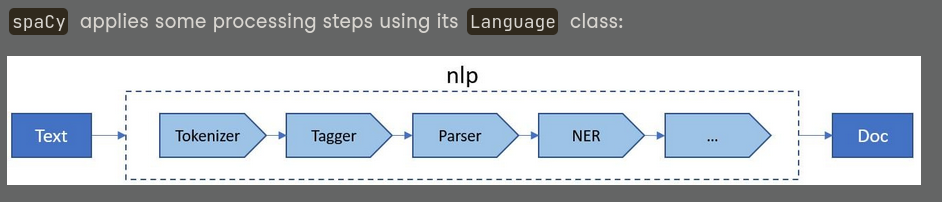

### Container objects in spaCy
in spaCy there are 3 main container objects:

- `Doc`: Represents the entire processed text
- `Span`: Represents a slice of a Doc
- `Token`: Represents a single token in the Doc

### Pipeline components

- The spaCy language processing pipeline always depends on the loaded model and its capabilities.

| Component        | Name       | Description                                    |
| ---------------- | ---------- | ---------------------------------------------- |
| Tokenizer        | Tokenizer  | Segment text into tokens and create Doc object |
| Tagger           | Tagger     | Assign part-of-speech tags                     |
| Lemmatizer       | Lemmatizer | Reduce the words to their root forms           |
| EntityRecognizer | NER        | Detect and label named entities                |

#### Tokenization

- always the first operation
- All the other operations need it
- Tokens can be words, nums and puncs

#### Sentence segmentation

- More complex than tokenization
- Is a part of DependencyParser component

In [9]:
import spacy
nlp = spacy.load("en_core_web_sm")

text = "We are learning NLP. This course introduces spaCy."
doc = nlp(text)
for sent in doc.sents:
    print(sent.text)

We are learning NLP.
This course introduces spaCy.


- Lemmatization
- A lemma is the base form of a token
- The lemma of eats and ate is eat
- Improves accuracy of language models


In [10]:
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("We are seeing her after one year.")
print([(token.text, token.lemma_) for token in doc])

[('We', 'we'), ('are', 'be'), ('seeing', 'see'), ('her', 'she'), ('after', 'after'), ('one', 'one'), ('year', 'year'), ('.', '.')]


#### Running a spaCy pipeline

You've already run a spaCy NLP pipeline on a single piece of text and also extracted tokens of a given list of Doc containers. In this exercise, you'll practice the initial steps of running a spaCy pipeline on texts, which is a list of text strings.

You will use the en_core_web_sm model for this purpose. The spaCy package has already been imported for you.

In [12]:
texts = ['A loaded spaCy model can be used to compile documents list!',
 'Tokenization is the first step in any spacy pipeline.']

# Run an nlp model on each item of texts and append the Doc container to documents
documents = []
for text in texts:
  documents.append(nlp(text))
  
# Print the token texts for each Doc container
for doc in documents:
  print([token.text for token in doc])

['A', 'loaded', 'spaCy', 'model', 'can', 'be', 'used', 'to', 'compile', 'documents', 'list', '!']
['Tokenization', 'is', 'the', 'first', 'step', 'in', 'any', 'spacy', 'pipeline', '.']


#### Lemmatization with spaCy

In this exercise, you will practice lemmatization. Lemmatization can be helpful to generate the root form of derived words. This means that given any sentence, we expect the number of lemmas to be less than or equal to the number of tokens.

The first Amazon food review is provided for you in a string called text. en_core_web_sm is loaded as nlp, and has been run on the text to compile document, a Doc container for the text string.

tokens, a list containing tokens for the text is also already loaded for your use.

In [14]:
text = 'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

document = nlp(text)
tokens = [token.text for token in document]

# Append the lemma for all tokens in the document
lemmas = [token.lemma_ for token in document]
print("Lemmas:\n", lemmas, "\n")

# Print tokens and compare with lemmas list
print("Tokens:\n", tokens)

Lemmas:
 ['I', 'have', 'buy', 'several', 'of', 'the', 'Vitality', 'can', 'dog', 'food', 'product', 'and', 'have', 'find', 'they', 'all', 'to', 'be', 'of', 'good', 'quality', '.', 'the', 'product', 'look', 'more', 'like', 'a', 'stew', 'than', 'a', 'process', 'meat', 'and', 'it', 'smell', 'well', '.', 'my', 'Labrador', 'be', 'finicky', 'and', 'she', 'appreciate', 'this', 'product', 'well', 'than', ' ', 'most', '.'] 

Tokens:
 ['I', 'have', 'bought', 'several', 'of', 'the', 'Vitality', 'canned', 'dog', 'food', 'products', 'and', 'have', 'found', 'them', 'all', 'to', 'be', 'of', 'good', 'quality', '.', 'The', 'product', 'looks', 'more', 'like', 'a', 'stew', 'than', 'a', 'processed', 'meat', 'and', 'it', 'smells', 'better', '.', 'My', 'Labrador', 'is', 'finicky', 'and', 'she', 'appreciates', 'this', 'product', 'better', 'than', ' ', 'most', '.']


#### Sentence segmentation with spaCy

In this exercise, you will practice sentence segmentation. In NLP, segmenting a document into its sentences is a useful basic operation. It is one of the first steps in many NLP tasks that are more elaborate, such as detecting named entities. Additionally, capturing the number of sentences may provide some insight into the amount of information provided by the text.

You can access ten food reviews in the list called texts.

The `en_core_web_sm` model has already been loaded for you as nlp and .

In [18]:
texts = ['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".',
 'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.',
 'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.',
 'Great taffy at a great price.  There was a wide assortment of yummy taffy.  Delivery was very quick.  If your a taffy lover, this is a deal.',
 'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a bit too much red/black licorice-flavored pieces (just not my particular favorites). Between me, my kids, and my husband, this lasted only two weeks! I would recommend this brand of taffy -- it was a delightful treat.',
 "This saltwater taffy had great flavors and was very soft and chewy.  Each candy was individually wrapped well.  None of the candies were stuck together, which did happen in the expensive version, Fralinger's.  Would highly recommend this candy!  I served it at a beach-themed party and everyone loved it!",
 'This taffy is so good.  It is very soft and chewy.  The flavors are amazing.  I would definitely recommend you buying it.  Very satisfying!!',
 "Right now I'm mostly just sprouting this so my cats can eat the grass. They love it. I rotate it around with Wheatgrass and Rye too",
 'This is a very healthy dog food. Good for their digestion. Also good for small puppies. My dog eats her required amount at every feeding.']

# Generating a documents list of all Doc containers
documents = [nlp(text) for text in texts]

# Iterate through documents and append sentences in each doc to the sentences list
sentences = []
for doc in documents:
  sentences.append([s for s in doc.sents])
  
# Find number of sentences per each doc container
print([s for s in sentences])
print([len(s) for s in sentences])

[[I have bought several of the Vitality canned dog food products and have found them all to be of good quality., The product looks more like a stew than a processed meat and it smells better., My Labrador is finicky and she appreciates this product better than  most.], [Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted., Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".], [This is a confection that has been around a few centuries.  , It is a light, pillowy citrus gelatin with nuts - in this case Filberts., And it is cut into tiny squares and then liberally coated with powdered sugar.  , And it is a tiny mouthful of heaven.  , Not too chewy, and very flavorful.  , I highly recommend this yummy treat.  , If you are familiar with the story of C.S. Lewis' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.], [If you are

## Linguistic features in spaCy

### Part-of-speech(POS) tagging

- Categorizing words grammatically, based on function and context within a sentence
- POS tagging confirms the meaning of a word
- Some words such as **watch** can be both noun and verb
- `spaCy` captures POS tags in the `pos_` feature of the nlp pipeline

In [21]:
verb_sent = "I watch TV."
noun_sent = "I left without my watch."
print([(token.text,token.pos_,spacy.explain(token.pos_)) for token in nlp(verb_sent)])
print([(token.text,token.pos_,spacy.explain(token.pos_)) for token in nlp(noun_sent)])

[('I', 'PRON', 'pronoun'), ('watch', 'VERB', 'verb'), ('TV', 'NOUN', 'noun'), ('.', 'PUNCT', 'punctuation')]
[('I', 'PRON', 'pronoun'), ('left', 'VERB', 'verb'), ('without', 'ADP', 'adposition'), ('my', 'PRON', 'pronoun'), ('watch', 'NOUN', 'noun'), ('.', 'PUNCT', 'punctuation')]


### Named entity recognition
- A **named entity** is a word or phrase that refers to a specific entity with a name
- Named-entity recognition (NER) classifies named entities into pre-defined categories

| Entity type | Description                                   |
| ----------- | --------------------------------------------- |
| PERSON      | Named person or family                        |
| ORG         | Companies, institutions, etc.                 |
| GPE         | Geo-political entity: countries, cities, etc. |
| LOC         | Non-GPE locations: mountain ranges, etc.      |
| DATE        | Absolute or relative dates or periods         |
| TIME        | Time smaller than a day                       |

#### NER and spaCy
- `spaCy` models extract named entities using the `NER` pipeline component
- Named entities are available via the `doc.ents` property
- `spaCy` will also tag each entity with its entity label(`.label_`)

In [27]:
text = "shk is a data scientist"
doc = nlp(text)
print([(ent.text,ent.start_char,ent.end_char,ent.label_) for ent in doc.ents])
# we can also access entity types from tokens in doc
for token in doc:
    print((token.text, token.ent_type_))

[('shk', 0, 3, 'PERSON')]
('shk', 'PERSON')
('is', '')
('a', '')
('data', '')
('scientist', '')


### DisplaCy (visualization)

In [29]:
from spacy import displacy
displacy.serve(doc,style="ent")
# stop displacy


/home/shk/.local/lib/python3.14/site-packages/spacy/displacy/__init__.py:108: UserWarning: [W011] It looks like you're calling displacy.serve from within a Jupyter notebook or a similar environment. This likely means you're already running a local web server, so there's no need to make displaCy start another one. Instead, you should be able to replace displacy.serve with displacy.render to show the visualization.
  warnings.warn(Warnings.W011)



Using the 'ent' visualizer
Serving on http://0.0.0.0:5000 ...

Shutting down server on port 5000.


### Practice
#### POS tagging with spaCy

In this exercise, you will practice POS tagging. POS tagging is a useful tool in NLP as it allows algorithms to understand the grammatical structure of a sentence and to confirm words that have multiple meanings such as watch and play.

For this exercise, en_core_web_sm has been loaded for you as nlp. Three comments from the Airline Travel Information System (ATIS) dataset have been provided for you in a list called texts.

In [31]:
texts = ['What is the arrival time in San francisco for the 7:55 AM flight leaving Washington?',
 'Cheapest airfare from Tacoma to Orlando is 650 dollars.',
 'Round trip fares from Pittsburgh to Philadelphia are under 1000 dollars!']
# Compile a list of all Doc containers of texts
documents = [nlp(text) for text in texts]

# Print token texts and POS tags for each Doc container
for doc in documents:
    for token in doc:
        print("Text: ", token.text, "| POS tag: ", token.pos_)
    print("\n")

Text:  What | POS tag:  PRON
Text:  is | POS tag:  AUX
Text:  the | POS tag:  DET
Text:  arrival | POS tag:  NOUN
Text:  time | POS tag:  NOUN
Text:  in | POS tag:  ADP
Text:  San | POS tag:  PROPN
Text:  francisco | POS tag:  PROPN
Text:  for | POS tag:  ADP
Text:  the | POS tag:  DET
Text:  7:55 | POS tag:  NUM
Text:  AM | POS tag:  PROPN
Text:  flight | POS tag:  NOUN
Text:  leaving | POS tag:  VERB
Text:  Washington | POS tag:  PROPN
Text:  ? | POS tag:  PUNCT


Text:  Cheapest | POS tag:  PROPN
Text:  airfare | POS tag:  NOUN
Text:  from | POS tag:  ADP
Text:  Tacoma | POS tag:  PROPN
Text:  to | POS tag:  ADP
Text:  Orlando | POS tag:  PROPN
Text:  is | POS tag:  AUX
Text:  650 | POS tag:  NUM
Text:  dollars | POS tag:  NOUN
Text:  . | POS tag:  PUNCT


Text:  Round | POS tag:  ADJ
Text:  trip | POS tag:  NOUN
Text:  fares | POS tag:  NOUN
Text:  from | POS tag:  ADP
Text:  Pittsburgh | POS tag:  PROPN
Text:  to | POS tag:  ADP
Text:  Philadelphia | POS tag:  PROPN
Text:  are | P

#### NER with spaCy

Named entity recognition (NER) helps you to easily identify key elements of a given document, like names of people and places. It helps sort unstructured data and detect important information, which is crucial if you are dealing with large datasets. In this exercise, you will practice Named Entity Recognition.

`en_core_web_sm` has been loaded for you as `nlp`. Three comments from the Airline Travel Information System (ATIS) dataset have been provided for you in a list called `texts`.

In [32]:
# Compile a list of all Doc containers of texts
documents = [nlp(text) for text in texts]

# Print the entity text and label for the entities in each document
for doc in documents:
    print([(ent.text, ent.label_) for ent in doc.ents])
    
# Print the 6th token's text and entity type of the second document
print("\nText:", documents[1][5].text, "| Entity type: ", documents[1][5].ent_type_)

[('San francisco', 'GPE'), ('7:55 AM', 'TIME'), ('Washington', 'GPE')]
[('Tacoma', 'GPE'), ('Orlando', 'GPE'), ('650 dollars', 'MONEY')]
[('Pittsburgh', 'GPE'), ('Philadelphia', 'GPE'), ('1000 dollars', 'MONEY')]

Text: Orlando | Entity type:  GPE


#### Text processing with spaCy

Every NLP application consists of several text processing steps. You have already learned some of these steps, including tokenization, lemmatization, sentence segmentation and named entity recognition.

spaCy NLP Pipeline

In this exercise, you'll continue to practice with text processing steps in spaCy, such as breaking the text into sentences and extracting named entities. You will use the first five reviews from the Amazon Fine Food Reviews dataset for this exercise. You can access these reviews by using the texts object.

The en_core_web_sm model has already been loaded for you to use, and you can access it by using nlp. The list of Doc containers for each item in texts is also pre-loaded and accessible at documents.

In [35]:
# Create a list to store sentences of each Doc container in documents
sentences = [[sent for sent in doc.sents] for doc in documents]

# Create a list to track number of sentences per Doc container in documents
num_sentences = [len([sent for sent in doc.sents]) for doc in documents]
print("Number of sentences in documents:\n", num_sentences, "\n")

# Record entities text and corresponding label of the third Doc container
third_text_entities = [(ent.text, ent.label_) for ent in documents[2].ents]
print("Third text entities:\n", third_text_entities, "\n")

# Record first ten tokens and corresponding POS tag for the third Doc container
third_text_10_pos = [(token.text, token.pos_) for token in documents[2]][:10]
print("First ten tokens of third text:\n", third_text_10_pos)

Number of sentences in documents:
 [1, 1, 1] 

Third text entities:
 [('Pittsburgh', 'GPE'), ('Philadelphia', 'GPE'), ('1000 dollars', 'MONEY')] 

First ten tokens of third text:
 [('Round', 'ADJ'), ('trip', 'NOUN'), ('fares', 'NOUN'), ('from', 'ADP'), ('Pittsburgh', 'PROPN'), ('to', 'ADP'), ('Philadelphia', 'PROPN'), ('are', 'AUX'), ('under', 'ADP'), ('1000', 'NUM')]
